In [2]:
# imports
import os, glob, math
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
plt.rcParams['figure.figsize'] = (12,5)
print("TF", tf.__version__)

TF 2.20.0


In [3]:
# Data is in Drive, mount it.
from google.colab import drive
drive.mount('/content/drive')

# Set base folder where your dataset is.
BASE_DIR = '/content/drive/MyDrive/major_data'
os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/major_data


In [4]:
# LSTM training starts on all companies (MODEL 1)

feature_columns = [
    'Open','High','Low','Close','Volume',
    'Return','High_Low','Open_Close','Volume_Change'
]

timesteps   = 10
epochs      = 50
batch_size  = 32


In [5]:
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i - timesteps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

In [7]:
# Use the cleaned folder path
csv_files = glob.glob("/content/drive/MyDrive/major_data/cleaned/*.csv")
print("CSV files found:", csv_files)

processed_data = {}

for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)

    print(f"{company_name} raw shape: {df.shape}")  # Check if file has rows/columns

    # Only keep if df is not empty
    if df.shape[0] > 0:
        processed_data[company_name] = df

print("Companies loaded:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [8]:
# Paths
cleaned_folder = "/content/drive/MyDrive/major_data/cleaned"
csv_files = glob.glob(os.path.join(cleaned_folder, "*.csv"))
print("CSV files found:", csv_files)

# Create output folder
output_folder = "/content/drive/MyDrive/major_data/processed_with_features"
os.makedirs(output_folder, exist_ok=True)

# Processed data dictionary
processed_data = {}

# Loop through CSVs
for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    print(f"{company_name} raw shape: {df.shape}")

    # Standardize column names
    df.columns = df.columns.str.strip().str.capitalize()

    # Rename inconsistent columns if needed
    rename_dict = {'Date ': 'Date', 'Close': 'Close', 'Volume': 'Volume'}
    df.rename(columns=rename_dict, inplace=True)

    # Keep only necessary columns
    required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[[col for col in df.columns if col in required_cols]]

    # Convert numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    # Handle missing data
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

    # Convert Date to datetime & sort
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)
    df = df.sort_values('Date').reset_index(drop=True)

    print(f"{company_name} rows after numeric conversion: {df.shape[0]}")

    # Skip if not enough rows
    if df.shape[0] < 5:  # can adjust threshold based on your feature window
        print(f" Skipping {company_name}, not enough rows")
        continue


    # Feature creation for LSTM
    df['Return'] = df['Close'].pct_change()
    df['High_Low'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close'] = (df['Open'] - df['Close']) / df['Close']
    df['Volume_Change'] = df['Volume'].pct_change()

    # Drop first row which has NaN from pct_change
    df.dropna(inplace=True)

    # Save processed data
    processed_data[company_name] = df
    print(f" Features created for {company_name}: {df.shape}")

    output_file_path = os.path.join(output_folder, f"{company_name}_features.csv")
    df.to_csv(output_file_path, index=False)
    print(f"Saved processed file with features: {output_file_path}")

# Summary
print("Companies ready:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [9]:
# LSTM training starts on all companies (MODEL 1)

feature_columns = [
    'Open','High','Low','Close','Volume',
    'Return','High_Low','Open_Close','Volume_Change'
]

timesteps   = 10
epochs      = 50
batch_size  = 32


In [10]:
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i - timesteps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

In [11]:
all_lstm_models = {}

for company, df in processed_data.items():

    n = len(df)
    train_size = int(n * 0.70)
    val_size   = int(n * 0.15)

    train_df = df.iloc[:train_size]
    val_df   = df.iloc[train_size:train_size + val_size]
    test_df  = df.iloc[train_size + val_size:]

    # -------- Feature Scaling --------
    feature_scaler = MinMaxScaler()
    X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])
    X_val_scaled   = feature_scaler.transform(val_df[feature_columns])
    X_test_scaled  = feature_scaler.transform(test_df[feature_columns])

    # -------- Target Scaling --------
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(train_df[['Close']])
    y_val_scaled   = target_scaler.transform(val_df[['Close']])
    y_test_scaled  = target_scaler.transform(test_df[['Close']])

    # -------- Create Sequences --------
    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    X_val, y_val     = create_sequences(X_val_scaled, y_val_scaled, timesteps)
    X_test, y_test   = create_sequences(X_test_scaled, y_test_scaled, timesteps)

    all_lstm_models[company] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val,     'y_val': y_val,
        'X_test': X_test,   'y_test': y_test,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'timesteps': timesteps,
        'feature_columns': feature_columns,
        'type': 'lstm_model1'
    }

    print(f"{company} → Train:{X_train.shape[0]}, Val:{X_val.shape[0]}, Test:{X_test.shape[0]}")


Adani Enterprises Ltd → Train:1921, Val:403, Test:405
Adani ports and special Economic → Train:1921, Val:403, Test:405
Bajaj Finance Ltd → Train:1921, Val:403, Test:405
Axis Bank Ltd → Train:1924, Val:404, Test:405
Bajaj Finserv Ltd → Train:1921, Val:403, Test:405
Bharat Electronics Ltd → Train:789, Val:161, Test:162
Bharti Airtel Ltd → Train:1921, Val:403, Test:405
Eternal Ltd → Train:1921, Val:403, Test:405
HCL Technologies Ltd → Train:1917, Val:403, Test:404
HDFC Bank Ltd → Train:1921, Val:403, Test:405
Hindustan Unilever Ltd → Train:1921, Val:403, Test:405
ICICI Bank Ltd → Train:1921, Val:403, Test:405
ITC Ltd → Train:1921, Val:403, Test:405
Infosys Ltd → Train:1921, Val:403, Test:405
JSW Steel Ltd → Train:1921, Val:403, Test:405
Larsen and Toubro Ltd → Train:1921, Val:403, Test:405
Kotak Mahindra Bank Ltd → Train:1917, Val:403, Test:404
Mahindra and Mahindra Ltd → Train:1921, Val:403, Test:405
Maruti Suzuki India Ltd → Train:1921, Val:403, Test:405
NTPC Ltd → Train:1921, Val:403, 

In [12]:
# Folders to save models and history/plots
LSTM_1 = "/content/drive/MyDrive/major_data/LSTM_1"
os.makedirs(LSTM_1, exist_ok=True)

MODEL_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm_saved_model1"
os.makedirs(MODEL_DIR, exist_ok=True)

HIST_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm1_history"
os.makedirs(HIST_DIR, exist_ok=True)

PLOT_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm1_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

METRICS_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm1_metrics"
os.makedirs(METRICS_DIR, exist_ok=True)


In [13]:
# Train LSTM models and save history
MODEL_TAG = "lstm_model1"

for company, data in all_lstm_models.items():

    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    #  Train and save history
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    data['model'] = model
    data['history'] = history  # Save history for plotting


    print(f" LSTM trained for {company}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0068 - val_loss: 0.0034
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0036
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0055
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.5230e-04 - val_loss: 0.0046
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3036e-04 - val_loss: 0.0032
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.9003e-04 - val_loss: 0.0030
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4086e-04 - val_loss: 0.0045
Epoch 10/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.8355e-04 - val_loss: 0.0033
Epoch 11/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.8232e-04 - val_loss: 0.0028
Epoch 12/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8m

In [14]:
import json
import joblib
#  Save LSTM model 1, directory
MODEL_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm_saved_model1"
os.makedirs(MODEL_DIR, exist_ok=True)

for company, data in all_lstm_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    company_dir = os.path.join(MODEL_DIR, safe_name)
    os.makedirs(company_dir, exist_ok=True)

    #  Save LSTM model
    model_path = os.path.join(company_dir, "lstm_model.keras")
    data['model'].save(model_path)

    #  Save scalers
    joblib.dump(data['feature_scaler'],
                os.path.join(company_dir, "feature_scaler.pkl"))

    joblib.dump(data['target_scaler'],
                os.path.join(company_dir, "target_scaler.pkl"))

    #  Save metadata
    metadata = {
        "timesteps": data['timesteps'],
        "feature_columns": data['feature_columns']
    }

    with open(os.path.join(company_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    print(f" Saved model & scalers for {company}")


 Saved model & scalers for Adani Enterprises Ltd
 Saved model & scalers for Adani ports and special Economic
 Saved model & scalers for Bajaj Finance Ltd
 Saved model & scalers for Axis Bank Ltd
 Saved model & scalers for Bajaj Finserv Ltd
 Saved model & scalers for Bharat Electronics Ltd
 Saved model & scalers for Bharti Airtel Ltd
 Saved model & scalers for Eternal Ltd
 Saved model & scalers for HCL Technologies Ltd
 Saved model & scalers for HDFC Bank Ltd
 Saved model & scalers for Hindustan Unilever Ltd
 Saved model & scalers for ICICI Bank Ltd
 Saved model & scalers for ITC Ltd
 Saved model & scalers for Infosys Ltd
 Saved model & scalers for JSW Steel Ltd
 Saved model & scalers for Larsen and Toubro Ltd
 Saved model & scalers for Kotak Mahindra Bank Ltd
 Saved model & scalers for Mahindra and Mahindra Ltd
 Saved model & scalers for Maruti Suzuki India Ltd
 Saved model & scalers for NTPC Ltd
 Saved model & scalers for Oil and Natural Gas Corporation Ltd
 Saved model & scalers for 

In [15]:
for company, data in all_lstm_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    history = data['history']  # History from the training step

    # Plot training history
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{company} LSTM Training History")
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)

    # Save plot
    plot_path = os.path.join(HIST_DIR, f"{safe_name}_history.png")
    plt.savefig(plot_path)
    plt.close()

    print(f" Training history plot saved for {company}")

 Training history plot saved for Adani Enterprises Ltd
 Training history plot saved for Adani ports and special Economic
 Training history plot saved for Bajaj Finance Ltd
 Training history plot saved for Axis Bank Ltd
 Training history plot saved for Bajaj Finserv Ltd
 Training history plot saved for Bharat Electronics Ltd
 Training history plot saved for Bharti Airtel Ltd
 Training history plot saved for Eternal Ltd
 Training history plot saved for HCL Technologies Ltd
 Training history plot saved for HDFC Bank Ltd
 Training history plot saved for Hindustan Unilever Ltd
 Training history plot saved for ICICI Bank Ltd
 Training history plot saved for ITC Ltd
 Training history plot saved for Infosys Ltd
 Training history plot saved for JSW Steel Ltd
 Training history plot saved for Larsen and Toubro Ltd
 Training history plot saved for Kotak Mahindra Bank Ltd
 Training history plot saved for Mahindra and Mahindra Ltd
 Training history plot saved for Maruti Suzuki India Ltd
 Training hi

In [16]:
# EVALUATION
metrics_list = []

for company, data in all_lstm_models.items():
    model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Store in master list (same as before)
    metrics_list.append({
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    })

    # Save individual company metrics
    company_metrics_df = pd.DataFrame([{
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    }])

    # Create safe file name
    company_safe = company.replace(" ", "_")

    company_metrics_df.to_csv(
        os.path.join(METRICS_DIR, f"{company_safe}_metrics.csv"),
        index=False
    )

# Save combined metrics
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(
    os.path.join(METRICS_DIR, "A_lstm1_test_metrics.csv"),
    index=False
)

print("All company test metrics saved (combined + individual files).")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
All company test metrics saved (combined

In [17]:
for company, data in all_lstm_models.items():

    model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)

    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"{company}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print("-"*40)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Adani Enterprises Ltd
RMSE: 111.57
MAE : 80.52
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Adani ports and special Economic
RMSE: 17.61
MAE : 14.78
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Bajaj Finance Ltd
RMSE: 665.39
MAE : 191.34
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Axis Bank Ltd
RMSE: 58.10
MAE : 47.37
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Bajaj Finserv Ltd
RMSE: 97.83
MAE : 84.57
----------------------------------------
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Bharat Electronics Ltd
RMSE: 14.96
MAE : 11.97
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Bharti Airtel Ltd
RMSE: 485.51
MAE : 464.21
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Eternal Ltd
RMSE: 23.65
MAE : 17.67
----------------------------------------

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


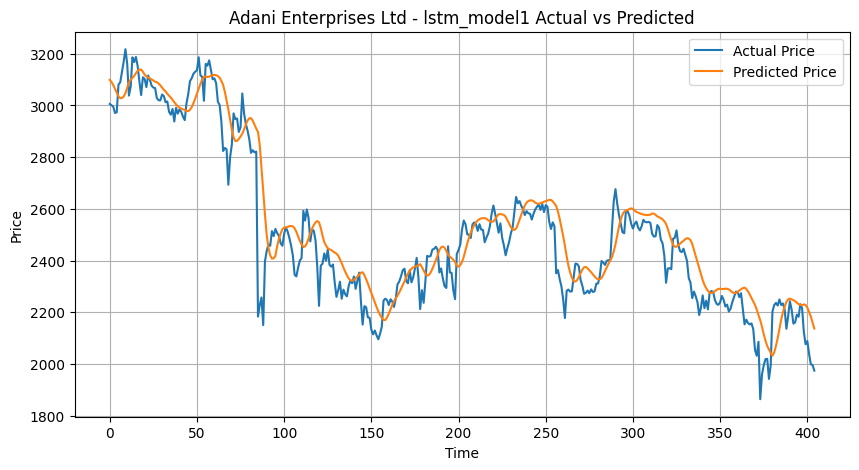

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Adani_Enterprises_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


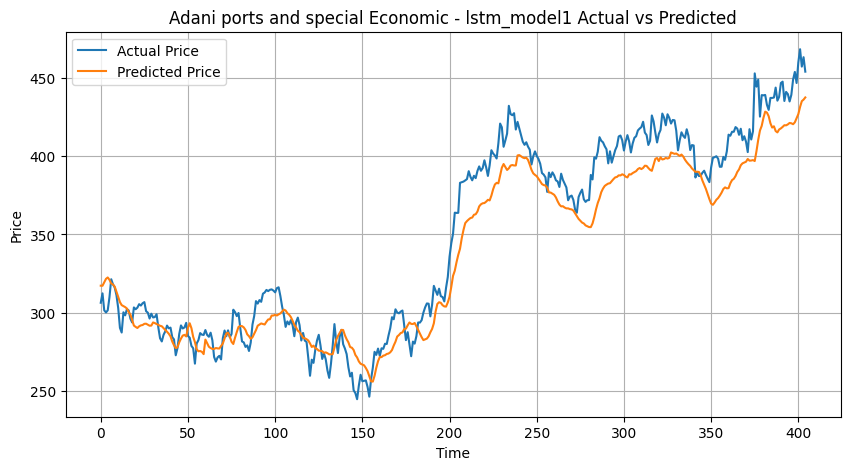

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Adani_ports_and_special_Economic_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


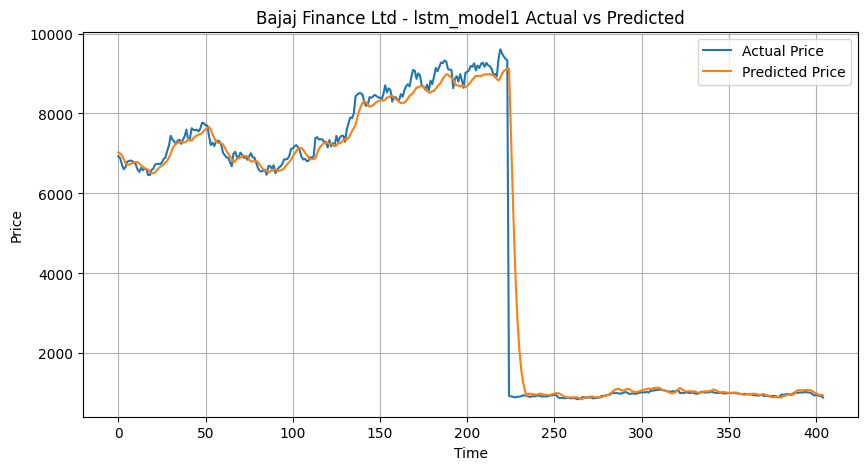

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Bajaj_Finance_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


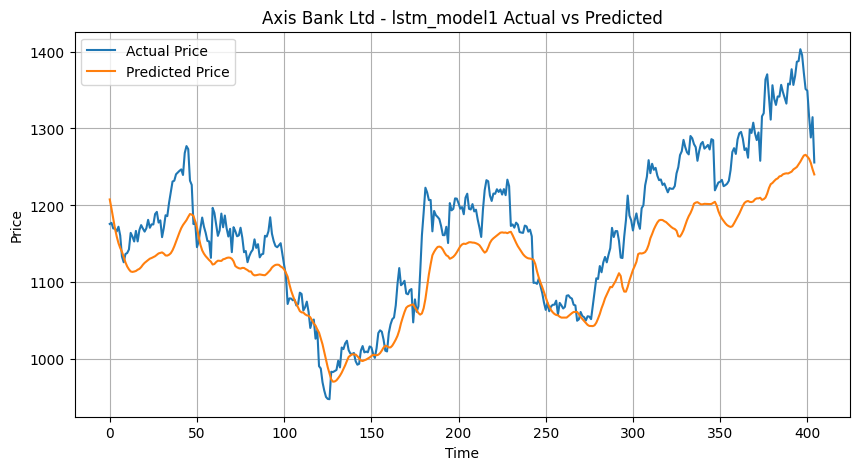

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Axis_Bank_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


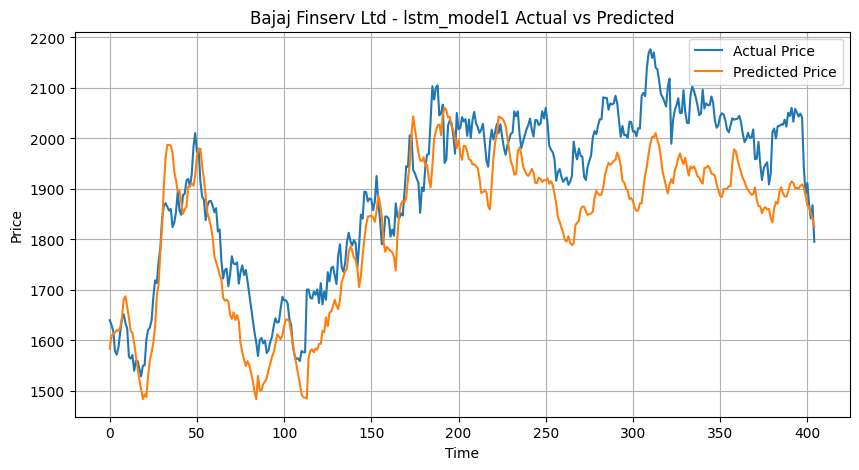

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Bajaj_Finserv_Ltd_lstm_model1_actual_vs_pred.png
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


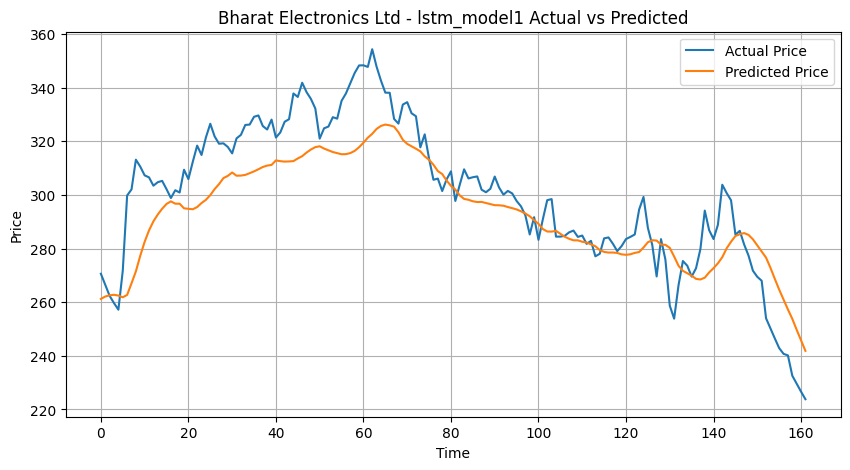

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Bharat_Electronics_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


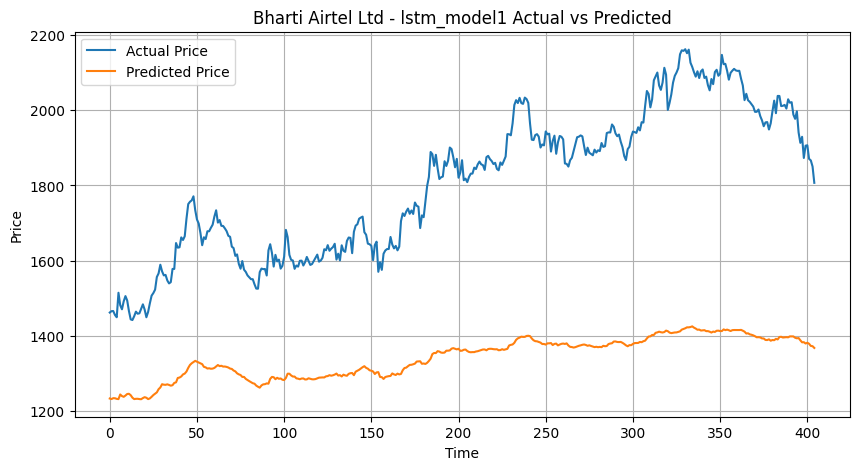

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Bharti_Airtel_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


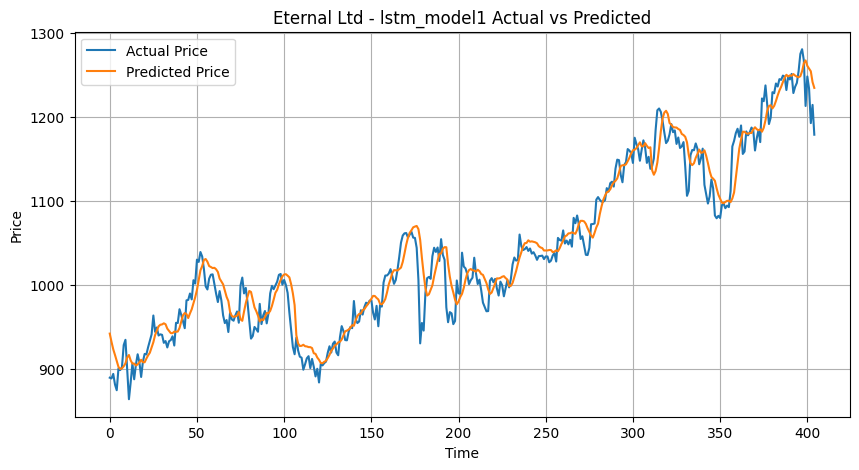

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Eternal_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


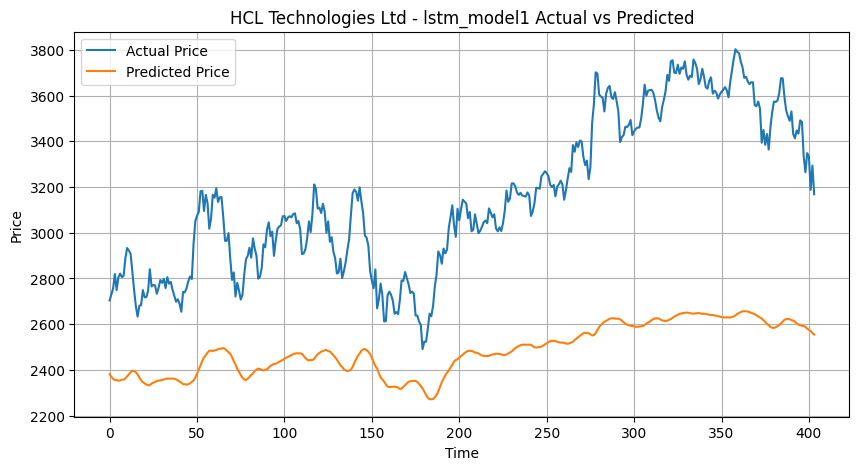

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/HCL_Technologies_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


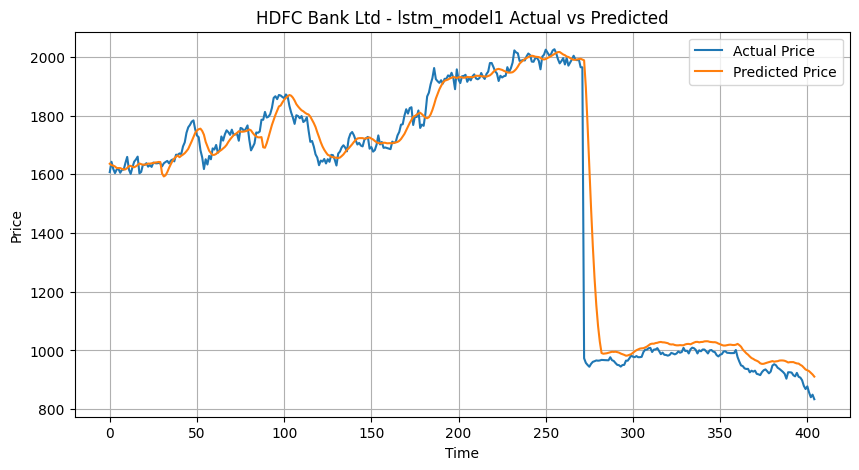

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/HDFC_Bank_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


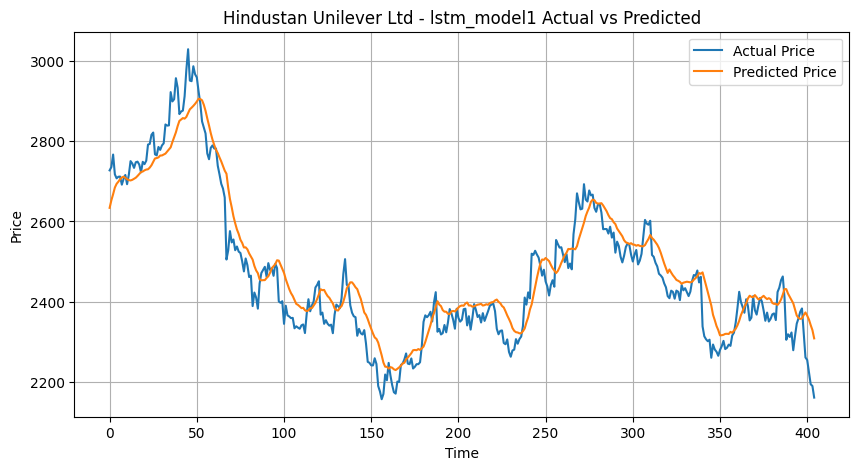

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Hindustan_Unilever_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


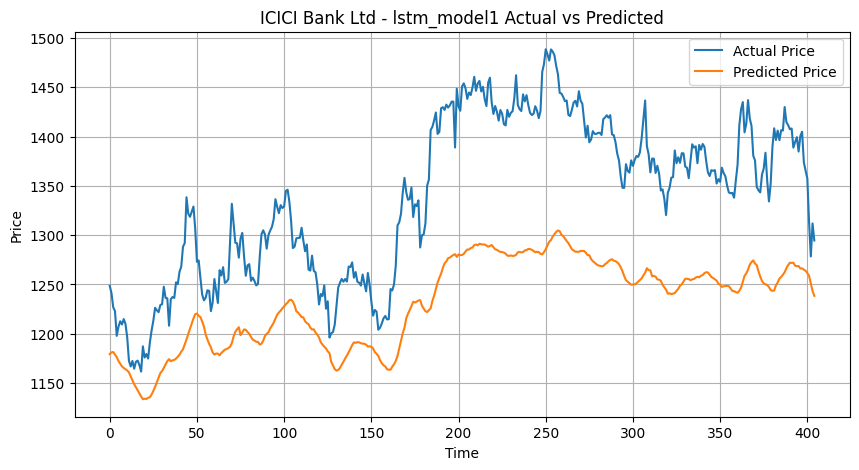

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/ICICI_Bank_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


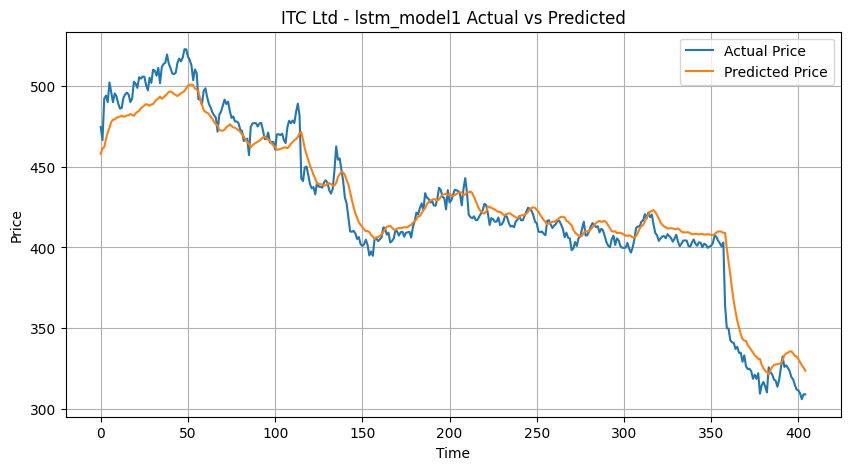

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/ITC_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


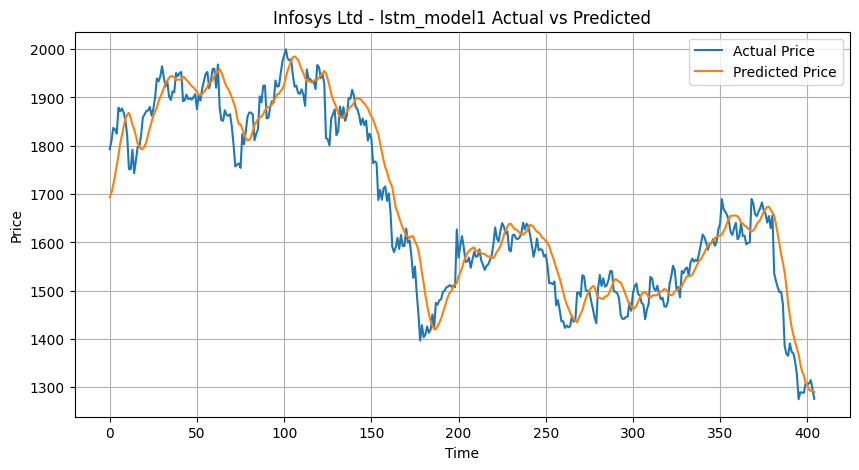

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Infosys_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


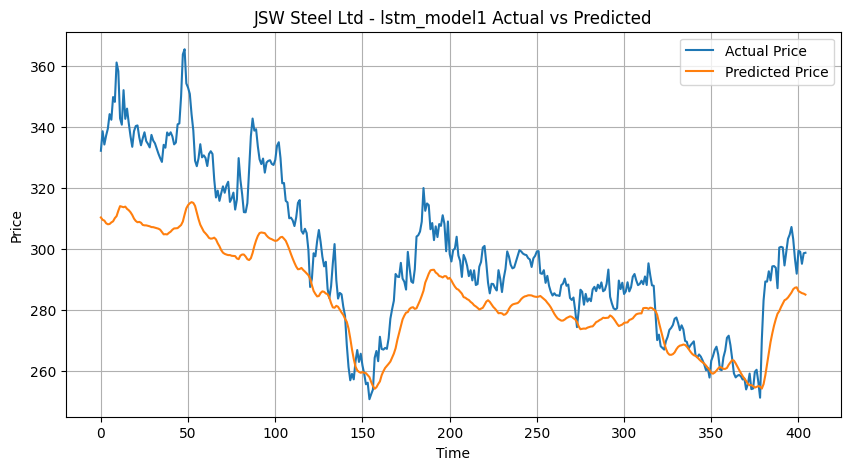

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/JSW_Steel_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


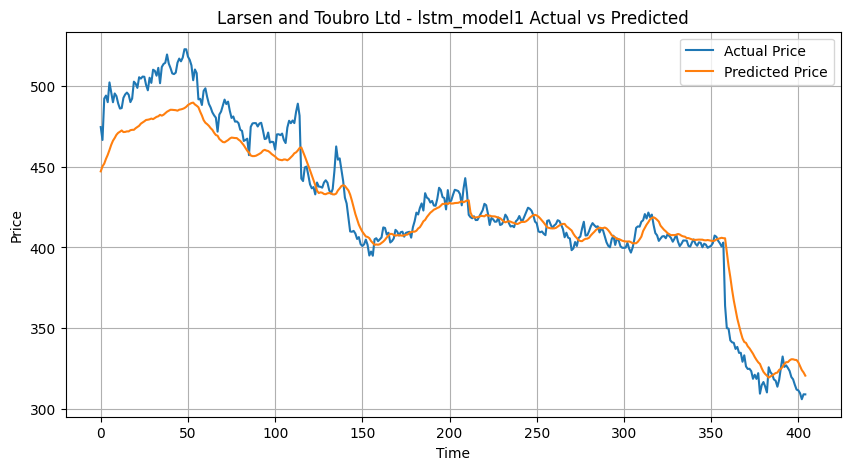

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Larsen_and_Toubro_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


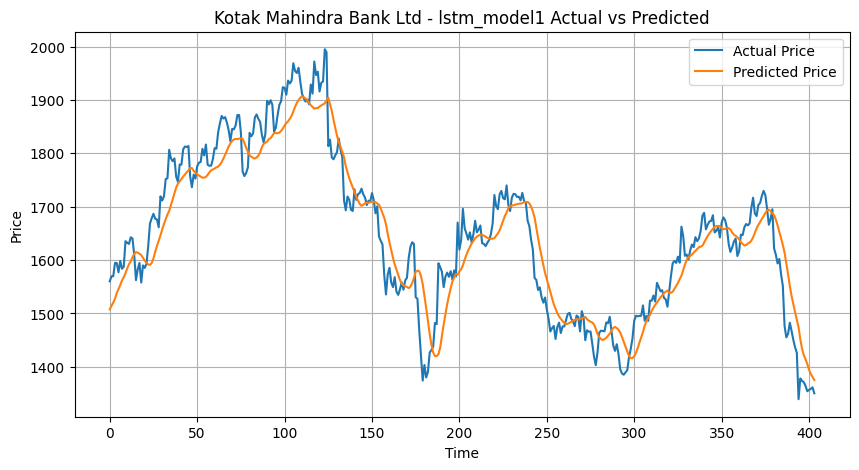

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Kotak_Mahindra_Bank_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


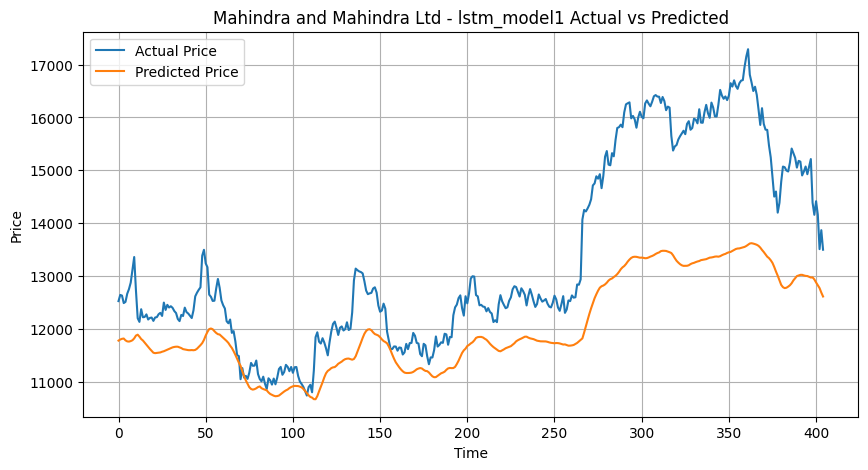

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Mahindra_and_Mahindra_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


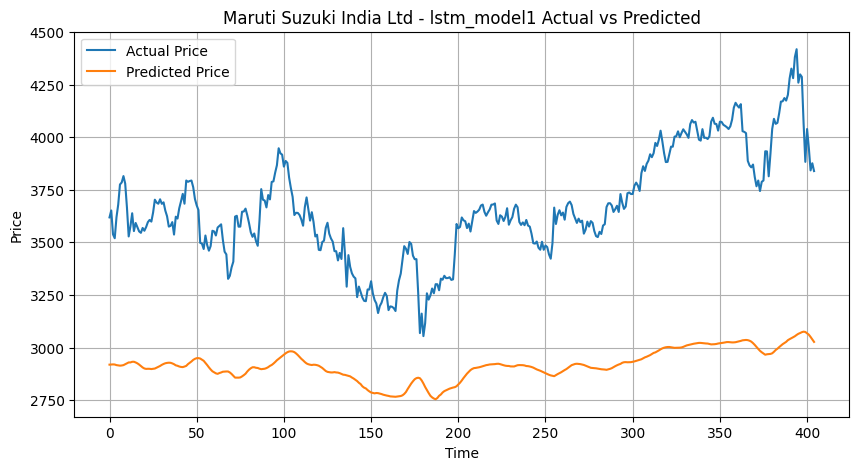

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Maruti_Suzuki_India_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


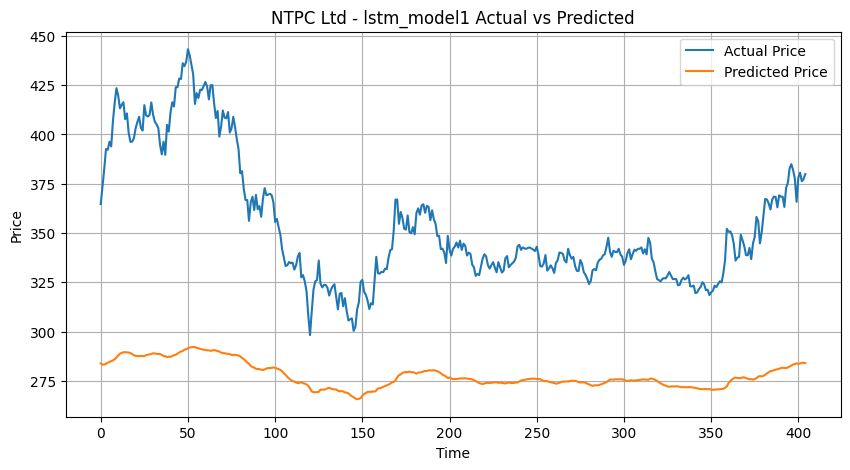

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/NTPC_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


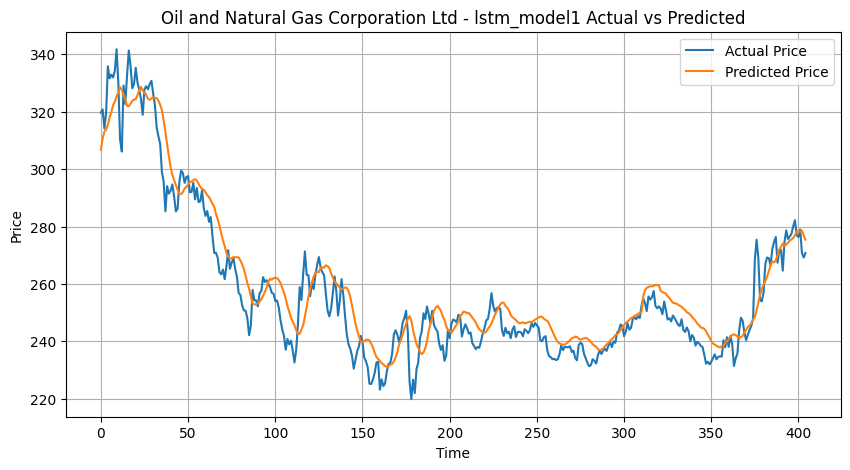

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Oil_and_Natural_Gas_Corporation_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


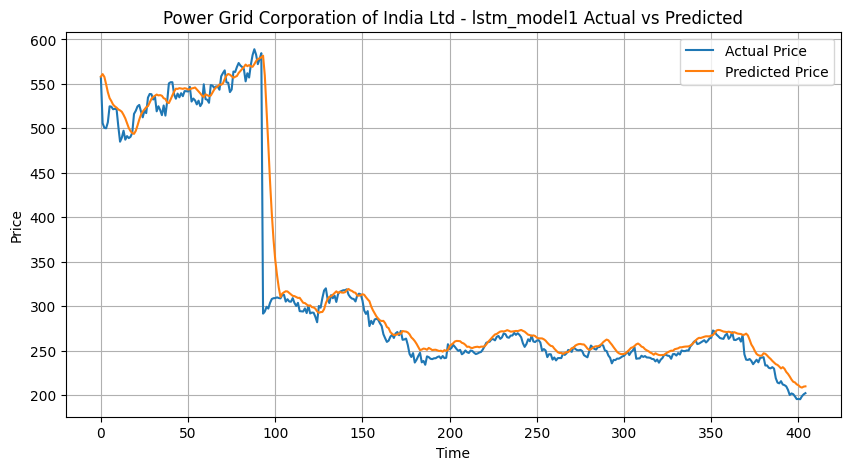

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Power_Grid_Corporation_of_India_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


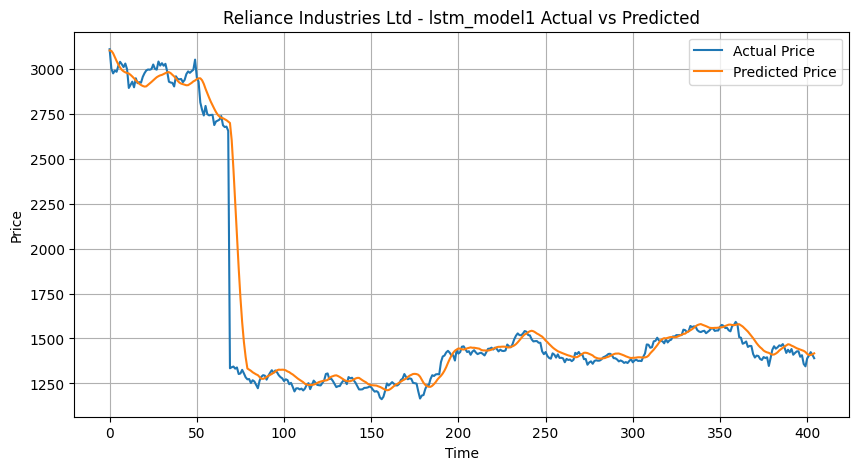

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Reliance_Industries_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


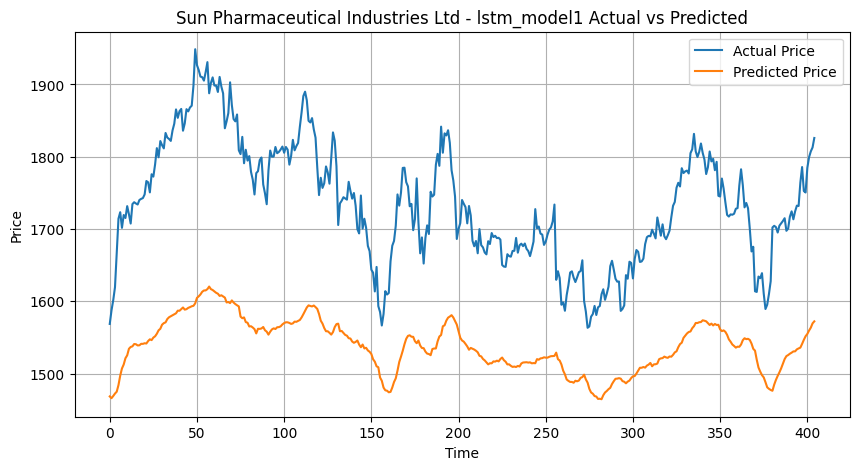

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Sun_Pharmaceutical_Industries_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


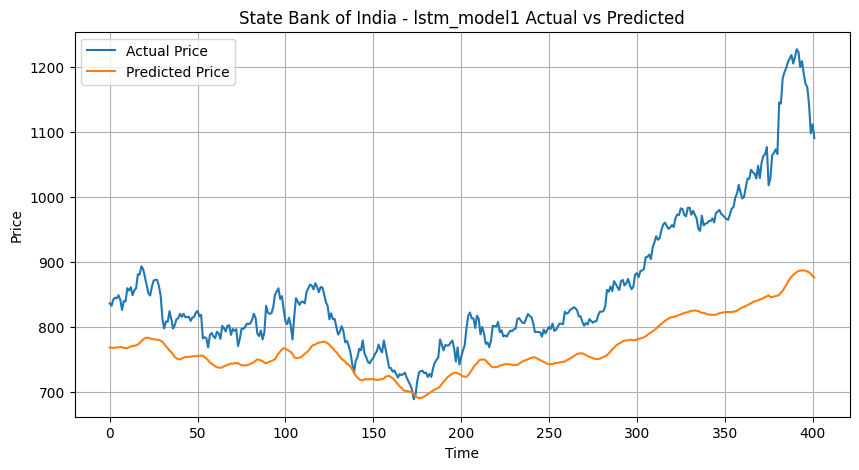

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/State_Bank_of_India_lstm_model1_actual_vs_pred.png
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


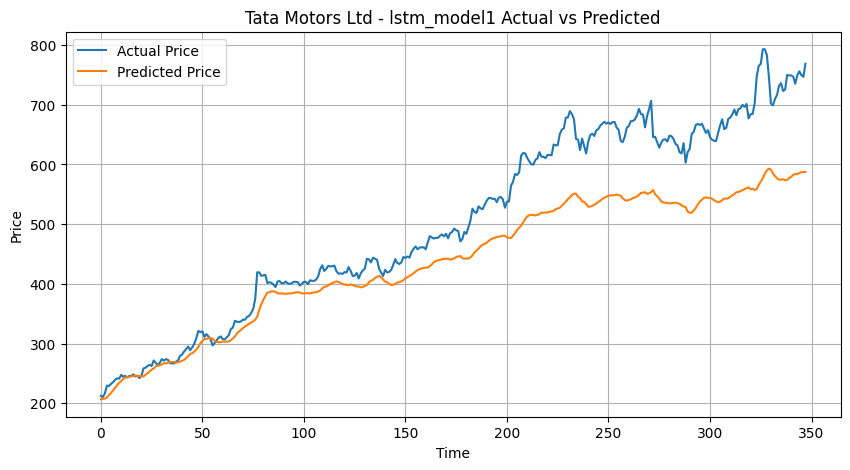

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Tata_Motors_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


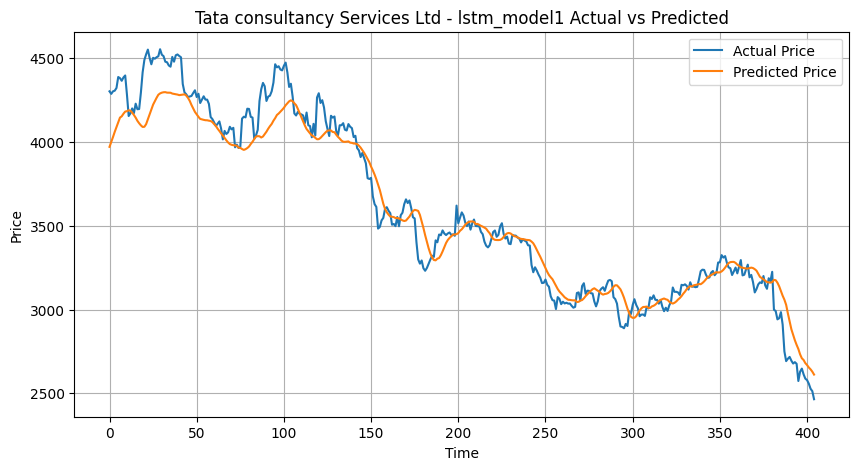

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Tata_consultancy_Services_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


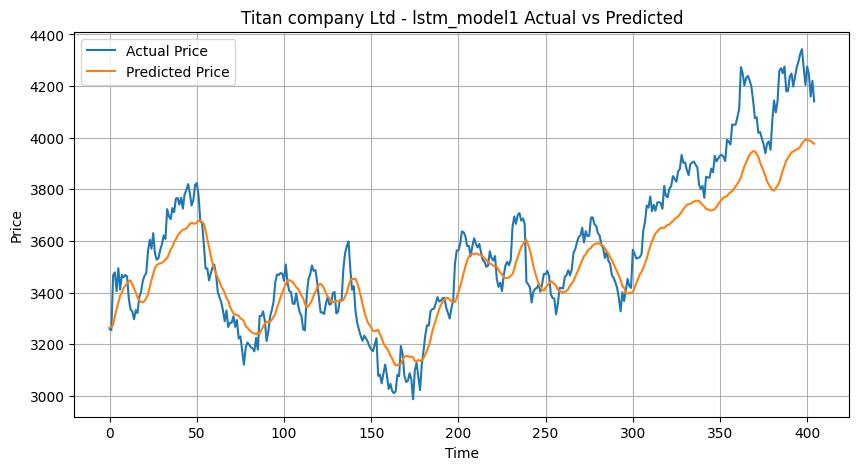

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Titan_company_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


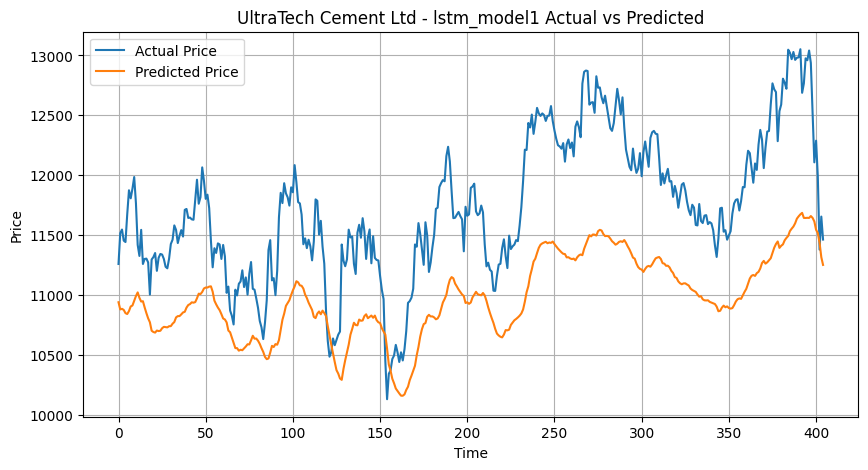

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/UltraTech_Cement_Ltd_lstm_model1_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


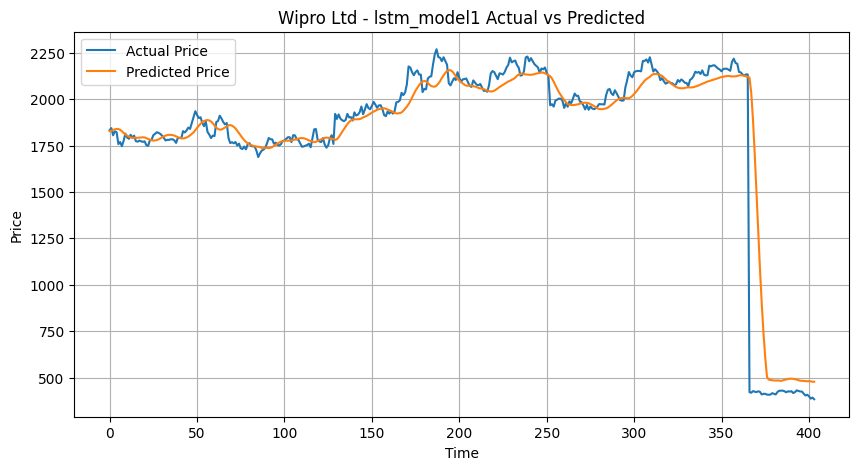

Plot saved at: /content/drive/MyDrive/major_data/LSTM_1/lstm1_plots/Wipro_Ltd_lstm_model1_actual_vs_pred.png


In [18]:
import matplotlib.pyplot as plt
import os
import numpy as np

for company, data in all_lstm_models.items():

    model = data['model']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # Predict
    y_pred = model.predict(X_test)

    # Inverse scale
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test_inv, label="Actual Price")
    plt.plot(y_pred_inv, label="Predicted Price")
    plt.title(f"{company} - {MODEL_TAG} Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

    # Save plot
    safe_name = company.replace(" ", "_").replace(".", "")
    plot_path = os.path.join(PLOT_DIR, f"{safe_name}_{MODEL_TAG}_actual_vs_pred.png")
    plt.savefig(plot_path)
    plt.show()

    print(f"Plot saved at: {plot_path}")


In [19]:
# PREDICTION
from datetime import timedelta

def predict_future_lstm(company, all_lstm_models, processed_data, feature_columns, n_future=5):

    data = all_lstm_models[company]
    model = data['model']
    feature_scaler = data['feature_scaler']
    target_scaler  = data['target_scaler']
    timesteps      = data['timesteps']

    df = processed_data[company].copy()

    scaled_features = feature_scaler.transform(df[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):
        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        next_row = current_seq[-1].copy()
        next_row[feature_columns.index('Close')] = pred_scaled
        current_seq = np.vstack([current_seq[1:], next_row])

    future_dates = [
        df['Date'].iloc[-1] + timedelta(days=i+1)
        for i in range(n_future)
    ]

    return pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')


In [20]:
all_lstm_predictions = {}

for company in all_lstm_models.keys():

    pred_df = predict_future_lstm(
        company=company,
        all_lstm_models=all_lstm_models,
        processed_data=processed_data,
        feature_columns=feature_columns,
        n_future=5
    )

    all_lstm_predictions[company] = pred_df

    print(f" Future prediction done for {company}")


 Future prediction done for Adani Enterprises Ltd
 Future prediction done for Adani ports and special Economic
 Future prediction done for Bajaj Finance Ltd
 Future prediction done for Axis Bank Ltd
 Future prediction done for Bajaj Finserv Ltd
 Future prediction done for Bharat Electronics Ltd
 Future prediction done for Bharti Airtel Ltd
 Future prediction done for Eternal Ltd
 Future prediction done for HCL Technologies Ltd
 Future prediction done for HDFC Bank Ltd
 Future prediction done for Hindustan Unilever Ltd
 Future prediction done for ICICI Bank Ltd
 Future prediction done for ITC Ltd
 Future prediction done for Infosys Ltd
 Future prediction done for JSW Steel Ltd
 Future prediction done for Larsen and Toubro Ltd
 Future prediction done for Kotak Mahindra Bank Ltd
 Future prediction done for Mahindra and Mahindra Ltd
 Future prediction done for Maruti Suzuki India Ltd
 Future prediction done for NTPC Ltd
 Future prediction done for Oil and Natural Gas Corporation Ltd
 Futur

In [21]:
from datetime import timedelta
import numpy as np
import pandas as pd

n_future = 5
all_predictions = {}

close_index = feature_columns.index('Close')

for company, data in all_lstm_models.items():

    model = data['model']
    feature_scaler = data['feature_scaler']
    target_scaler = data['target_scaler']
    timesteps = data['timesteps']

    df = processed_data[company].copy()

    scaled_features = feature_scaler.transform(df[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):
        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        next_row = current_seq[-1].copy()
        next_row[close_index] = pred_scaled
        current_seq = np.vstack([current_seq[1:], next_row])

    last_date = df['Date'].iloc[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(n_future)]

    pred_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')

    all_predictions[company] = pred_df

    print(f"{company} next {n_future} days predicted")


Adani Enterprises Ltd next 5 days predicted
Adani ports and special Economic next 5 days predicted
Bajaj Finance Ltd next 5 days predicted
Axis Bank Ltd next 5 days predicted
Bajaj Finserv Ltd next 5 days predicted
Bharat Electronics Ltd next 5 days predicted
Bharti Airtel Ltd next 5 days predicted
Eternal Ltd next 5 days predicted
HCL Technologies Ltd next 5 days predicted
HDFC Bank Ltd next 5 days predicted
Hindustan Unilever Ltd next 5 days predicted
ICICI Bank Ltd next 5 days predicted
ITC Ltd next 5 days predicted
Infosys Ltd next 5 days predicted
JSW Steel Ltd next 5 days predicted
Larsen and Toubro Ltd next 5 days predicted
Kotak Mahindra Bank Ltd next 5 days predicted
Mahindra and Mahindra Ltd next 5 days predicted
Maruti Suzuki India Ltd next 5 days predicted
NTPC Ltd next 5 days predicted
Oil and Natural Gas Corporation Ltd next 5 days predicted
Power Grid Corporation of India Ltd next 5 days predicted
Reliance Industries Ltd next 5 days predicted
Sun Pharmaceutical Industrie

In [22]:
for company, pred in all_predictions.items():
    print(company)
    print(pred)
    print("-" * 40)

Adani Enterprises Ltd
            Predicted_Close
Date                       
2026-03-12      2114.028067
2026-03-13      2095.633628
2026-03-14      2080.872932
2026-03-15      2069.733149
2026-03-16      2064.510967
----------------------------------------
Adani ports and special Economic
            Predicted_Close
Date                       
2026-03-12       437.845720
2026-03-13       437.485182
2026-03-14       436.915807
2026-03-15       436.749223
2026-03-16       437.848448
----------------------------------------
Bajaj Finance Ltd
            Predicted_Close
Date                       
2026-03-12       903.880191
2026-03-13       839.834013
2026-03-14       768.048072
2026-03-15       693.996518
2026-03-16       615.684031
----------------------------------------
Axis Bank Ltd
            Predicted_Close
Date                       
2026-03-12      1229.585547
2026-03-13      1217.535099
2026-03-14      1205.475896
2026-03-15      1194.512347
2026-03-16      1185.011787
------

In [23]:
import os
import shutil
import pandas as pd

# Convert dictionary of predictions to a single DataFrame
final_pred_df = pd.concat(all_predictions, axis=1)
final_pred_df.columns = [col[0] for col in final_pred_df.columns]  # clean column labels
final_pred_df.index.name = 'Date'

# Main output file
output_path = "/content/drive/MyDrive/major_data/Future/LSTM_1/model1_future_predictions.csv"

# Ensure parent folder exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# If a directory accidentally exists with same name → remove it
if os.path.isdir(output_path):
    shutil.rmtree(output_path)

# Save combined predictions
final_pred_df.to_csv(output_path)

# Save individual company predictions
individual_folder = "/content/drive/MyDrive/major_data/Future/LSTM_1/model1_individual_predictions"
os.makedirs(individual_folder, exist_ok=True)

for company in final_pred_df.columns:
    company_safe = company.replace(" ", "_")

    company_df = final_pred_df[[company]]  # select single column
    company_df.to_csv(
        os.path.join(individual_folder, f"{company_safe}_future.csv")
    )

print(f"Combined file saved: {output_path}")
print(f"Individual company files saved in: {individual_folder}")

Combined file saved: /content/drive/MyDrive/major_data/Future/LSTM_1/model1_future_predictions.csv
Individual company files saved in: /content/drive/MyDrive/major_data/Future/LSTM_1/model1_individual_predictions


In [24]:
# RECOMMENDATION / RANKING
def expected_return(last_price, future_price):
    return ((future_price - last_price) / last_price) * 100

In [25]:
lstm_ranking = []

for company in all_lstm_models.keys():

    pred_df = predict_future_lstm(
        company,
        all_lstm_models,
        processed_data,
        feature_columns,
        n_future=5
    )

    last_close = processed_data[company]['Close'].iloc[-1]
    future_close = pred_df['Predicted_Close'].iloc[-1]

    ret = expected_return(last_close, future_close)

    lstm_ranking.append({
        'Company': company,
        'Last_Close': round(last_close, 2),
        'Predicted_Close_5D': round(future_close, 2),
        'Expected_Return_%': round(ret, 2)
    })

# Create DataFrame
ranking_df = pd.DataFrame(lstm_ranking)

# Sort by return
ranking_df = ranking_df.sort_values(by='Expected_Return_%', ascending=False)

# Take TOP 10
top10_df = ranking_df.head(10).reset_index(drop=True)

# Add Rank column
top10_df.insert(0, 'Rank', range(1, len(top10_df) + 1))

# Display
top10_df

,Rank,Company,Last_Close,Predicted_Close_5D,Expected_Return_%
0,1,Wipro Ltd,383.20,483.41,26.15
1,2,Power Grid Corporation of India Ltd,202.23,218.99,8.29
2,3,HDFC Bank Ltd,833.95,876.71,5.13
3,4,Adani Enterprises Ltd,1974.70,2064.51,4.55
4,5,ITC Ltd,309.00,321.68,4.10
5,6,Bharat Electronics Ltd,223.80,230.83,3.14
6,7,Reliance Industries Ltd,1390.20,1432.60,3.05
7,8,Tata consultancy Services Ltd,2464.90,2535.23,2.85
8,9,Larsen and Toubro Ltd,309.00,317.04,2.60
9,10,Hindustan Unilever Ltd,2161.40,2207.19,2.12


In [26]:
import os

# Path to existing folder
LSTM_RANKING_DIR = "/content/drive/MyDrive/major_data/Ranking"
os.makedirs(LSTM_RANKING_DIR, exist_ok=True)

# Create DataFrame (your code already did this)
ranking_df = pd.DataFrame(lstm_ranking)
ranking_df = ranking_df.sort_values(
    by='Expected_Return_%',
    ascending=False
).reset_index(drop=True)

# Save file
file_path = os.path.join(LSTM_RANKING_DIR, "LSTM_1_top_ranking.csv")
ranking_df.to_csv(file_path, index=False)

print(f" Ranking saved successfully at:\n{file_path}")


 Ranking saved successfully at:
/content/drive/MyDrive/major_data/Ranking/LSTM_1_top_ranking.csv


In [27]:
import os

#  Create folder for saving test results
PRED_RESULTS_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm1_predicted_prices"
os.makedirs(PRED_RESULTS_DIR, exist_ok=True)

#  Save predicted vs actual for each company
for company, data in all_lstm_models.items():
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = data['model'].predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    test_df = pd.DataFrame({
        'Actual_Close': y_true.flatten(),
        'Predicted_Close': y_pred.flatten()
    })

    file_path = os.path.join(PRED_RESULTS_DIR, f"{company.replace(' ', '_')}_test_results.csv")
    test_df.to_csv(file_path, index=False)
    print(f" Test results saved for {company}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for Adani Enterprises Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for Adani ports and special Economic
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for Bajaj Finance Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
 Test results saved for Axis Bank Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
 Test results saved for Bajaj Finserv Ltd
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
 Test results saved for Bharat Electronics Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for Bharti Airtel Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
 Test results saved for Eternal Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for HCL Technologies Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for HDFC Bank Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for Hindustan Unilever Ltd
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
 Test results saved for ICICI Bank Ltd
13/1

In [28]:
# Load LSTM_1 model
MODEL_DIR = "/content/drive/MyDrive/major_data/LSTM_1/lstm_saved_model1"

lstm1_models = {}

for company_folder in os.listdir(MODEL_DIR):

    company_path = os.path.join(MODEL_DIR, company_folder)

    if os.path.isdir(company_path):

        company_name = company_folder.replace("_", " ")

        model = load_model(os.path.join(company_path, "lstm_model.keras"))

        feature_scaler = joblib.load(
            os.path.join(company_path, "feature_scaler.pkl")
        )

        target_scaler = joblib.load(
            os.path.join(company_path, "target_scaler.pkl")
        )

        with open(os.path.join(company_path, "metadata.json"), "r") as f:
            metadata = json.load(f)

        lstm1_models[company_name] = {
            "model": model,
            "feature_scaler": feature_scaler,
            "target_scaler": target_scaler,
            "timesteps": metadata["timesteps"],
            "feature_columns": metadata["feature_columns"]
        }

        print(f" Loaded LSTM Model1 for {company_name}")

print("\n All LSTM Model1 loaded successfully!")

 Loaded LSTM Model1 for Adani Enterprises Ltd
 Loaded LSTM Model1 for Adani ports and special Economic
 Loaded LSTM Model1 for Bajaj Finance Ltd
 Loaded LSTM Model1 for Axis Bank Ltd
 Loaded LSTM Model1 for Bajaj Finserv Ltd
 Loaded LSTM Model1 for Bharat Electronics Ltd
 Loaded LSTM Model1 for Bharti Airtel Ltd
 Loaded LSTM Model1 for Eternal Ltd
 Loaded LSTM Model1 for HCL Technologies Ltd
 Loaded LSTM Model1 for HDFC Bank Ltd
 Loaded LSTM Model1 for Hindustan Unilever Ltd
 Loaded LSTM Model1 for ICICI Bank Ltd
 Loaded LSTM Model1 for ITC Ltd
 Loaded LSTM Model1 for Infosys Ltd
 Loaded LSTM Model1 for JSW Steel Ltd
 Loaded LSTM Model1 for Larsen and Toubro Ltd
 Loaded LSTM Model1 for Kotak Mahindra Bank Ltd
 Loaded LSTM Model1 for Mahindra and Mahindra Ltd
 Loaded LSTM Model1 for Maruti Suzuki India Ltd
 Loaded LSTM Model1 for NTPC Ltd
 Loaded LSTM Model1 for Oil and Natural Gas Corporation Ltd
 Loaded LSTM Model1 for Power Grid Corporation of India Ltd
 Loaded LSTM Model1 for Relian